# Task 3.2 - Failure Mode

**Failure scenario:** I use an almost linearly separable dataset and then steadily increase the diversity weight `mu`. I expected the method to struggle here because, on an easy problem with one dominant separating direction, forcing multiple learners to become too different can conflict with accuracy instead of improving it.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from submission_support.drm_support import run_failure_experiment, save_failure_plot

result = run_failure_experiment()
plot_path = save_failure_plot(result)
result["records"]

[{'mu': 0.0,
  'train_error': 0.004807692307692291,
  'test_error': 0.0,
  'alignment': 1.0},
 {'mu': 0.02,
  'train_error': 0.004807692307692291,
  'test_error': 0.0,
  'alignment': 1.0},
 {'mu': 0.05,
  'train_error': 0.004807692307692291,
  'test_error': 0.0,
  'alignment': 1.0},
 {'mu': 0.1,
  'train_error': 0.004807692307692291,
  'test_error': 0.0,
  'alignment': 1.0},
 {'mu': 0.18,
  'train_error': 0.004807692307692291,
  'test_error': 0.0,
  'alignment': 0.8799175011064071},
 {'mu': 0.3,
  'train_error': 0.125,
  'test_error': 0.1071428571428571,
  'alignment': 0.8689185420334624}]

This code sweeps the diversity weight on an easy dataset and records train/test error at each setting. The experiment directly targets the paper's core assumption that useful diversity exists; it asks what happens when that assumption is weak because the task really prefers nearly the same separating direction for every good classifier.

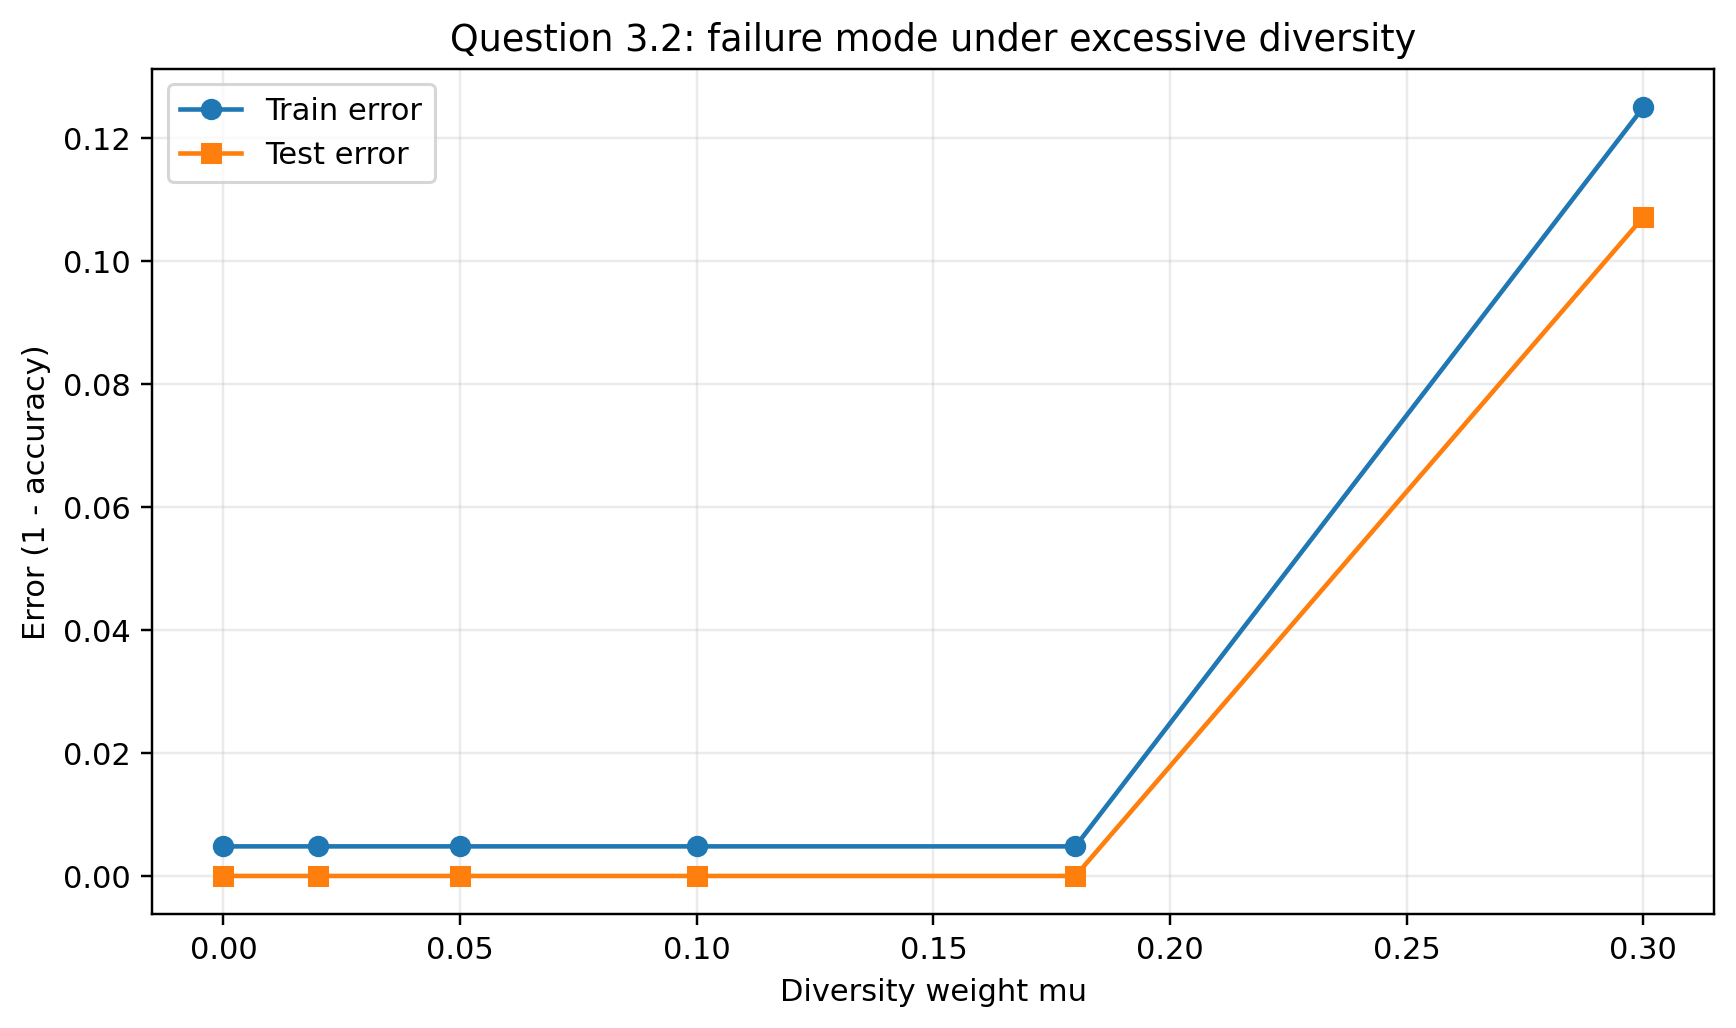

In [2]:
from IPython.display import Image, display

display(Image(filename=str(plot_path)))

The clearest failure appears when `mu` grows from the best observed setting **0.00** to the worst observed setting **0.30**, where test error rises from **0.0000** to **0.1071**. This happens because the dataset already has an easy and stable separating direction, so the ensemble does not need strong diversity to solve it. Once the diversity pressure becomes too large, the method spends optimization effort pushing learners away from each other instead of allowing them to concentrate around the best separator. That directly links back to the assumption in Task 1.2 that multiple accurate-yet-diverse learners must exist for DRM to help. In this failure case, that assumption is weak, so diversity becomes a burden rather than a benefit. The result is therefore a useful negative example: explicit diversity is powerful only when the data distribution offers room for complementary solutions.

**One possible modification:** A practical fix would be to make `mu` data-adaptive, for example by selecting it with cross-validation or by shrinking it automatically when the component learners are already sufficiently different.